In [ ]:
# Autosave de figuras em PDF com subpastas por área
from pathlib import Path
import os
import unicodedata
from typing import Optional, Dict, Tuple, Any

import matplotlib
import matplotlib.pyplot as plt

# Diretório base: cria sempre "imagens" no diretório atual

def get_base_images_dir() -> Path:
    base = Path('imagens')
    base.mkdir(parents=True, exist_ok=True)
    return base

IMAGES_BASE_DIR = get_base_images_dir()

# Mapeamento de palavras-chave -> categoria
KEYWORD_TO_CATEGORY: Dict[str, str] = {
    # Trajetória
    'trajectory': 'trajetoria',
    'trajetoria': 'trajetoria',
    'trajetória': 'trajetoria',
    # Estabilidade
    'stability': 'estabilidade',
    'static margin': 'estabilidade',
    'stability margin': 'estabilidade',
    # Aerodinâmica
    'drag': 'aerodinamica',
    'lift': 'aerodinamica',
    'aerodynamic': 'aerodinamica',
    'arrasto': 'aerodinamica',
    # Cinemática
    'velocity': 'cinematica',
    'speed': 'cinematica',
    'altitude': 'cinematica',
    'altura': 'cinematica',
    'acceleration': 'cinematica',
    'aceleração': 'cinematica',
    'descent': 'cinematica',
    'angular velocity': 'cinematica',
    # Forças
    'force': 'forcas',
    'forces': 'forcas',
    'thrust': 'forcas',
    'peso': 'forcas',
    # Propulsão
    'motor': 'propulsao',
    'burn': 'propulsao',
    'queima': 'propulsao',
    'impulse': 'propulsao',
    'impulso': 'propulsao',
    'propellant': 'propulsao',
    # Geometria
    'rocket': 'geometria',
    'foguete': 'geometria',
    'geometry': 'geometria',
    'representação': 'geometria',
    'representacao': 'geometria',
}


def ensure_dir(path: Path) -> Path:
    path.mkdir(parents=True, exist_ok=True)
    return path


def strip_accents(text: str) -> str:
    return ''.join(ch for ch in unicodedata.normalize('NFKD', text) if not unicodedata.combining(ch))


def slugify(text: str) -> str:
    if not text:
        return ''
    text = strip_accents(text).lower()
    allowed = 'abcdefghijklmnopqrstuvwxyz0123456789-_ '
    text = ''.join(ch if ch in allowed else '-' for ch in text)
    text = text.replace(' ', '-')
    while '--' in text:
        text = text.replace('--', '-')
    return text.strip('-_')


def filesafe_name(text: str) -> str:
    """Sanitiza um nome preservando acentos e espaços; remove apenas caracteres ilegais.
    Compatível com Windows/Linux/macOS e ideal para nomes de figuras.
    """
    if text is None:
        return ''
    name = str(text).replace('\n', ' ').strip()
    if not name:
        return ''
    forbidden = '<>:"/\\|?*'
    name = ''.join('-' if ch in forbidden else ch for ch in name)
    # Colapsa múltiplos espaços
    name = ' '.join(name.split())
    # Evita finalizar com ponto/espaço (Windows)
    name = name.rstrip(' .')
    return name


def figure_title(fig: matplotlib.figure.Figure) -> str:
    try:
        if getattr(fig, '_suptitle', None) is not None:
            txt = fig._suptitle.get_text()
            if txt:
                return txt
    except Exception:
        pass
    try:
        axes = fig.get_axes()
        for ax in axes:
            t = getattr(ax, 'get_title', lambda: '')()
            if t:
                return t
    except Exception:
        pass
    return ''


def categorize_from_text(text: str) -> str:
    text_l = text.lower()
    for key, cat in KEYWORD_TO_CATEGORY.items():
        if key in text_l:
            return cat
    return 'outros'


def categorize_figure(fig: matplotlib.figure.Figure) -> str:
    title = figure_title(fig)
    if title:
        return categorize_from_text(title)
    try:
        axes = fig.get_axes()
        for ax in axes:
            lab = ''
            if hasattr(ax, 'get_xlabel'):
                lab += ' ' + ax.get_xlabel()
            if hasattr(ax, 'get_ylabel'):
                lab += ' ' + ax.get_ylabel()
            cat = categorize_from_text(lab)
            if cat != 'outros':
                return cat
    except Exception:
        pass
    return 'outros'


_saved_fig_ids: Dict[int, int] = {}
_counter: int = 1


def next_filename(fig: matplotlib.figure.Figure) -> Tuple[str, str]:
    global _counter
    title = figure_title(fig)
    if not title:
        try:
            axes = fig.get_axes()
            if axes:
                ax0 = axes[0]
                xlab = ax0.get_xlabel() if hasattr(ax0, 'get_xlabel') else ''
                ylab = ax0.get_ylabel() if hasattr(ax0, 'get_ylabel') else ''
                if ylab and xlab:
                    title = f'{ylab} vs {xlab}'
                else:
                    title = ylab or xlab
        except Exception:
            pass
    raw_name = title.strip() if title else f'Figura {_counter:03d}'
    base_name = filesafe_name(raw_name)
    _counter += 1
    category = categorize_figure(fig)
    return base_name, category


def save_figure_pdf(
    fig: matplotlib.figure.Figure,
    base_name: Optional[str] = None,
    category: Optional[str] = None,
) -> Path:
    fig_id = id(fig)
    version = _saved_fig_ids.get(fig_id, 0)
    if base_name is None or category is None:
        auto_name, auto_cat = next_filename(fig)
        base_name = base_name or auto_name
        category = category or auto_cat

    out_dir = ensure_dir(IMAGES_BASE_DIR / category)
    file_path = out_dir / f'{base_name}.pdf'
    if version > 0:
        file_path = out_dir / f'{base_name}-v{version+1}.pdf'

    fig.savefig(
        file_path,
        format='pdf',
        bbox_inches='tight',
        transparent=False,
        dpi=None,
    )
    _saved_fig_ids[fig_id] = version + 1
    return file_path


# Hook: salvar automaticamente após cada célula (Jupyter/Colab)
try:
    from IPython import get_ipython
    _ip = get_ipython()
    if _ip is not None:
        _last_seen: set[int] = set()

        def _post_run_cell_hook(result: Any):
            global _last_seen
            current = set(plt.get_fignums())
            new_nums = [n for n in current if n not in _last_seen]
            for n in new_nums:
                fig = plt.figure(n)
                try:
                    saved_path = save_figure_pdf(fig)
                    print(f'[auto-salvo] {saved_path}')
                except Exception as e:
                    print(f'[auto-salvo ERRO] figura {n}: {e}')
            _last_seen = current

        if not hasattr(_ip, '_falcon6_autosave_registered'):
            _ip.events.register('post_run_cell', _post_run_cell_hook)
            _ip._falcon6_autosave_registered = True
            print('[autosave] ativado: figuras serão salvas em PDF por célula')
except Exception as e:
    print(f'[autosave] não foi possível registrar o hook: {e}')


# Patch adicional: salvar quando plt.show() for chamado
try:
    _orig_show = plt.show

    def _show_and_save(*args, **kwargs):
        for n in plt.get_fignums():
            fig = plt.figure(n)
            try:
                save_figure_pdf(fig)
            except Exception:
                pass
        return _orig_show(*args, **kwargs)

    if getattr(plt.show, '__name__', '') != '_show_and_save':
        plt.show = _show_and_save
except Exception as e:
    print(f'[autosave] não foi possível patchar plt.show: {e}')


# API manual opcional

def salvar_todas_figuras():
    """Salva todas as figuras abertas em PDF dentro de 'imagens/<categoria>/'."""
    for n in plt.get_fignums():
        fig = plt.figure(n)
        try:
            save_figure_pdf(fig)
        except Exception as e:
            print(f'[salvar_todas_figuras ERRO] figura {n}: {e}')


# Suporte parcial a animações: salva PDF do 1º frame quando anim.save() é usado
try:
    import matplotlib.animation as manimation
    _orig_anim_save = manimation.Animation.save

    def _anim_save_with_pdf(self, filename, *args, **kwargs):
        out = _orig_anim_save(self, filename, *args, **kwargs)
        try:
            fig = getattr(self, '_fig', None)
            if fig is not None:
                from pathlib import Path as _P
                base = _P(filename).stem
                save_figure_pdf(fig, base_name=base, category='animacoes')
        except Exception:
            pass
        return out

    if getattr(manimation.Animation.save, '__name__', '') != '_anim_save_with_pdf':
        manimation.Animation.save = _anim_save_with_pdf
except Exception as e:
    print(f'[autosave] aviso: suporte a animação parcial: {e}')


[autosave] ativado: figuras serão salvas em PDF por célula


# Começando - RocketPy no Colab


Começamos configurando nosso ambiente. Para executar este notebook, vamos precisar:

- RocketPy
- Arquivos de dados (vamos baixar os dados do RocketPy do GitHub)

Portanto, vamos executar as seguintes linhas de código:

In [ ]:
%pip install rocketpy
!curl -o NACA0012-radians.txt https://raw.githubusercontent.com/RocketPy-Team/RocketPy/master/data/airfoils/NACA0012-radians.txt
!curl -o Cesaroni_M1670.eng https://raw.githubusercontent.com/RocketPy-Team/RocketPy/master/data/motors/cesaroni/Cesaroni_M1670.eng
!curl -o powerOffDragCurve.csv https://raw.githubusercontent.com/RocketPy-Team/RocketPy/master/data/rockets/FalconOneRocket/powerOffDragCurve.csv
!curl -o powerOnDragCurve.csv https://raw.githubusercontent.com/RocketPy-Team/RocketPy/master/data/rockets/FalconOneRocket/powerOnDragCurve.csv

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 382.2/382.2 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 118.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 89.3 MB/s eta 0:00:00
  Created wheel for simplekml: filename=simplekml-1.3.6-py3-none-any.whl size=65860 sha256=d7ddbc6dd53b3f655d2b82b116188da0365debdcfd4f6f47ed225f2167e28486
  Stored in directory: /root/.cache/pip/wheels/83/ee/f2/65cecfd948f1429ead035fd6d56bc6bd6574a636ddc4d65cbd
Successfully built simplekml
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  1052  100  1052    0     0   4638      0 --:--:-- --:--:-- --:--:--  4654
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 D

Agora podemos começar!

Aqui faremos uma simulação simplificada da trajetória de um foguete para você iniciar. Vamos começar importando o módulo rocketpy.


In [ ]:
from rocketpy import Environment, Flight, Rocket, SolidMotor

Recomenda-se executar a linha a seguir para que os gráficos do matplotlib exibidos adiante fiquem interativos e com maior qualidade.


In [ ]:
%config InlineBackend.figure_formats = ['svg']
%matplotlib inline

## Configurando uma Simulação


### Criando um Ambiente para o Spaceport America



A classe `Environment` é usada para definir a atmosfera, os ventos e os modelos de gravidade.

Você pode encontrar mais informações sobre a classe `Environment` na [Documentação de Uso da Classe Environment](https://docs.rocketpy.org/en/latest/notebooks/environment/environment_class_usage.html).

In [ ]:
# Configura as condições do local e data de lançamento
env = Environment(
    latitude=-21.90795,          # Latitude do local de lançamento (em graus decimais)
    longitude=-48.96156,         # Longitude do local de lançamento (em graus decimais)
    elevation=495            # Altitude do local de lançamento (em metros)
)

Para obter dados meteorológicos da previsão GFS, disponível online, executamos as linhas a seguir.

Primeiro, definimos a data de amanhã.


In [ ]:
import datetime

tomorrow = datetime.date.today() + datetime.timedelta(days=0)

env.set_date(
    (tomorrow.year, tomorrow.month, tomorrow.day, 11) # Hora em UTC
)

Em seguida, informamos ao `env` para usar uma previsão GFS a fim de obter as condições atmosféricas para o voo.

Não se preocupe com o aviso: ele apenas indica que nem todas as variáveis, como velocidade do vento ou temperatura atmosférica, estão disponíveis em todas as altitudes fornecidas pela previsão.


In [ ]:
env.set_atmospheric_model(type="Forecast", file="GFS")

/usr/local/lib/python3.12/dist-packages/rocketpy/environment/tools.py:309: UserWarning: Exact chosen launch time is not available in the provided file, using 2025-11-07 12:00:00 UTC instead.
  warnings.warn(


Podemos ver como estará o tempo chamando o método info!



Gravity Details

Acceleration of gravity at surface level:    9.7861 m/s²
Acceleration of gravity at  79.292 km (ASL): 9.5473 m/s²


Launch Site Details

Launch Date: 2025-11-07 13:00:00 UTC
Launch Site Latitude: -21.90795°
Launch Site Longitude: -48.96156°
Reference Datum: SIRGAS2000
Launch Site UTM coordinates: 90584.06 W    7572074.74 S
Launch Site UTM zone: 23K
Launch Site Surface Elevation: 471.5 m


Atmospheric Model Details

Atmospheric Model Type: Forecast
Forecast Maximum Height: 79.292 km
Forecast Time Period: from 2025-11-06 18:00:00 to 2025-11-22 18:00:00 utc
Forecast Hour Interval: 3 hrs
Forecast Latitude Range: From -90.0° to 90.0°
Forecast Longitude Range: From 0.0° to 359.75°

Surface Atmospheric Conditions

Surface Wind Speed: 5.20 m/s
Surface Wind Direction: 74.17°
Surface Wind Heading: 254.17°
Surface Pressure: 957.59 hPa
Surface Temperature: 296.98 K
Surface Air Density: 1.123 kg/m³
Surface Speed of Sound: 345.47 m/s


Earth Model Details

Earth Radius at Launch si

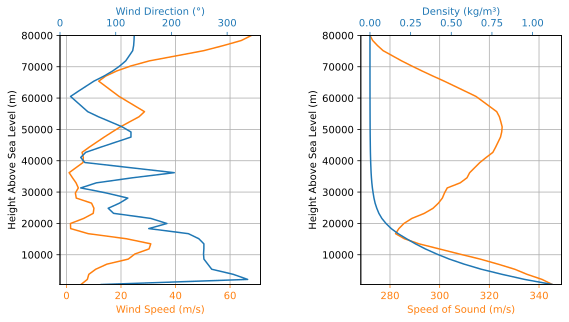

In [ ]:
env.info()

### Criando um Motor

Neste caso, é usado um motor de foguete sólido. Para criar um motor, utiliza-se a classe SolidMotor e fornecem-se os argumentos necessários.

A classe SolidMotor exige que o usuário tenha uma curva de empuxo pronta. Isso pode vir de um arquivo .eng para um motor comercial, como abaixo, ou de um arquivo .csv proveniente de uma medição de teste estático.

Além da curva de empuxo, também devem ser informados outros parâmetros, como propriedades dos grãos e dimensões do bocal.

Consulte a [Documentação de Uso da Classe SolidMotor](https://docs.rocketpy.org/en/latest/user/motors/solidmotor.html) para mais informações.


In [ ]:
# %%
# ------------------------- MOTOR -------------------------
from rocketpy import SolidMotor

FalconOne = SolidMotor(
    # Fonte da curva de empuxo
    thrust_source="meteor-RASP_Campeão.eng",

    # Tempo de queima em segundos
    burn_time=1.63,

    # Massa do motor vazio
    dry_mass=0.844,

    # Inércia do motor vazio (convertida de g*mm² para kg*m²)(Ixx_roll, Iyy_pitch, Izz_yaw)
    # Mapeamento: (SW.Lyy, SW.Lxx, SW.Lzz)
    dry_inertia=(0.02629, 0.02629, 0.000429),

    # Centro de massa seco do motor no seu sistema (origem no bocal)
    # Mapeamento: (SW.Y em metros)
    center_of_dry_mass_position=0.09727,

    # Posição da saída do bocal (origem do sistema do motor)
    nozzle_position=0.0,

    # Raio da SAÍDA do bocal em metros
    nozzle_radius=0.0126,

    # Raio da GARGANTA do bocal em metros
    throat_radius=0.0049,

    # Número de grãos de propelente
    grain_number=3,

    # Densidade do propelente em kg/m³
    grain_density=1884,

    # Raio externo do grão em metros
    grain_outer_radius=0.022,

    # Raio interno inicial do grão em metros
    grain_initial_inner_radius=0.010,

    # Altura/comprimento de um grão em metros
    grain_initial_height=0.100,

    # Separação entre os grãos em metros
    grain_separation=0.0005,

    # Posição do centro de massa dos grãos em metros (no sistema do motor)
    grains_center_of_mass_position=0.1902,

    # Orientação do sistema de coordenadas do motor
    coordinate_system_orientation="nozzle_to_combustion_chamber"
)



**Preste atenção especial aos parâmetros relacionados à *posição*:**
Mais detalhes em [Posições e Sistemas de Coordenadas](https://docs.rocketpy.org/en/latest/user/positions.html)


Para ver como é a nossa curva de empuxo, juntamente com outras propriedades importantes, chamamos o método info novamente. Você pode tentar o método all_info se quiser mais informações de uma só vez!


Nozzle Details
Nozzle Radius: 0.0126 m
Nozzle Throat Radius: 0.0049 m

Grain Details
Number of Grains: 3
Grain Spacing: 0.0005 m
Grain Density: 1884 kg/m3
Grain Outer Radius: 0.022 m
Grain Inner Radius: 0.01 m
Grain Height: 0.1 m
Grain Volume: 0.000 m3
Grain Mass: 0.227 kg

Motor Details
Total Burning Time: 1.63 s
Total Propellant Mass: 0.682 kg
Structural Mass Ratio: 0.553
Average Propellant Exhaust Velocity: 990.330 m/s
Average Thrust: 414.262 N
Maximum Thrust: 464.6671 N at 1.4518 s after ignition.
Total Impulse: 675.247 Ns



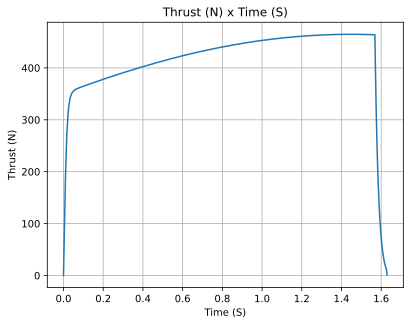

In [ ]:
# Imprime um resumo completo do motor para verificar se todos os dados foram carregados corretamente
FalconOne.info()


### Criando um Foguete


Um foguete é composto por vários componentes. Ou seja, devemos ter um motor (ainda bem que já temos o Pro75M1670 pronto), algumas superfícies aerodinâmicas (nariz, aletas e cauda) e paraquedas (se não estivermos lançando um míssil).

Você pode encontrar mais informações sobre a classe `Rocket` na [Documentação de Uso da Classe Rocket](https://docs.rocketpy.org/en/latest/user/rocket.html).

Vamos começar inicializando nosso foguete, chamado FalconOneRocket, inserindo propriedades de inércia, algumas dimensões e curvas de arrasto.

**Preste atenção especial aos parâmetros relacionados à *posição*:**
Mais detalhes em [Posições e Sistemas de Coordenadas](https://docs.rocketpy.org/en/latest/user/positions.html)



In [ ]:
# ------------------------- FOGUETE -------------------------
from rocketpy import Rocket

FalconOneRocket = Rocket(
    # Raio do foguete em metros (diâmetro máx. 7,96 cm -> raio 0,0398 m)
    radius=0.0398,

    # Massa do foguete SEM o motor em kg
    mass=3.385,

    # Inércia do foguete (Ixx, Iyy, Izz) em kg*m^2
    inertia=(0.615, 0.615, 0.00543),

    # Arquivo com a curva de arrasto com motor desligado
    power_off_drag='ArrastoCompletoV2.csv',

    # Arquivo com a curva de arrasto com motor ligado
    power_on_drag='ArrastoCompletoV2.csv',

    # Posição do centro de massa sem o motor em metros
    # Medido a partir da ponta da ogiva (ponta do foguete)
    center_of_mass_without_motor=0.735,

    coordinate_system_orientation="nose_to_tail"
)

Para adicionar o motor ao nosso foguete, basta informar qual motor estamos adicionando (Pro75M1670) e indicar a posição, em metros, da área de saída do bocal do motor em relação ao sistema de coordenadas previamente definido.


In [ ]:

# A 'position' é a distância (em metros) da ponta da ogiva até a saída do bocal do motor.
FalconOneRocket.add_motor(FalconOne, position=1.40)

#### Adicionando Superfícies Aerodinâmicas


Agora definimos as superfícies aerodinâmicas. Elas são bem diretas, exigindo atenção especial apenas aos valores de posição. Aqui vai um guia rápido:

- As posições fornecidas **devem** ser relativas ao mesmo sistema de coordenadas do foguete;
- A posição do nariz (nosecone) refere-se à ponta do nariz;
- A posição das aletas refere-se ao ponto pertencente à corda de raiz que é o mais alto no sistema de coordenadas do foguete;
- A posição da cauda refere-se ao ponto pertencente à cauda que é o mais alto no sistema de coordenadas do foguete.

Veja mais detalhes em [Posições e Sistemas de Coordenadas](https://docs.rocketpy.org/en/latest/user/positions.html)

In [ ]:
# Adiciona a Ogiva ao foguete
ogiva = FalconOneRocket.add_nose(
    length=0.228,       # Comprimento da ogiva em metros
    kind='powerseries',  # Parabólica (OpenRocket)
    power=1.0,
    position=0        # A ponta da ogiva é a origem (0) do foguete
)

# Adiciona as Aletas ao foguete
aletas = FalconOneRocket.add_trapezoidal_fins(
    n=4,
    root_chord=0.082, # comprimento da borda da aleta que está colada no corpo do foguete em metros.
    tip_chord=0.032, # O comprimento da borda externa da aleta (a ponta) em metros.
    span=0.114, # A altura da aleta, medida da raiz (no corpo) até a ponta em metros.
    position=1.26,
    cant_angle=0,
)

# Adiciona uma Cauda/Transição
cauda = FalconOneRocket.add_tail(
    top_radius=0.0398, # Raio que conecta no foguete em metros
    bottom_radius=0.025, # Raio externo em metros
    length=0.06,
    position=1.36 # Em relação a ogiva
)


Para ver todas as informações referentes ao foguete que acabamos de definir, executamos:


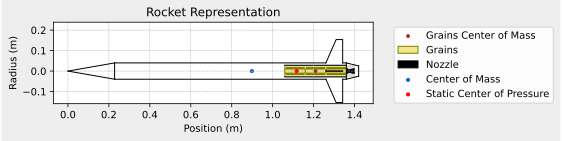

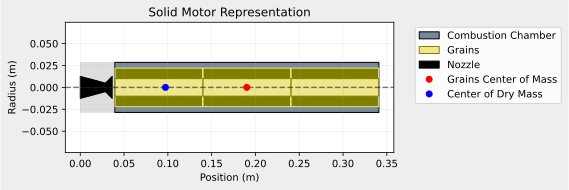

In [ ]:
# Verificando a representação do foguete
FalconOneRocket.plots.draw()
FalconOne.plots.draw()



Inertia Details

Rocket Mass: 3.385 kg (without motor)
Rocket Dry Mass: 4.229 kg (with unloaded motor)
Rocket Loaded Mass: 4.911 kg
Rocket Structural Mass Ratio: 0.861
Rocket Inertia (with unloaded motor) 11: 0.859 kg*m2
Rocket Inertia (with unloaded motor) 22: 0.859 kg*m2
Rocket Inertia (with unloaded motor) 33: 0.006 kg*m2
Rocket Inertia (with unloaded motor) 12: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 13: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 23: 0.000 kg*m2

Geometrical Parameters

Rocket Maximum Radius: 0.0398 m
Rocket Frontal Area: 0.004976 m2

Rocket Distances
Rocket Center of Dry Mass - Center of Mass without Motor: 0.113 m
Rocket Center of Dry Mass - Nozzle Exit: 0.552 m
Rocket Center of Dry Mass - Center of Propellant Mass: 0.361 m
Rocket Center of Mass - Rocket Loaded Center of Mass: 0.050 m


Aerodynamics Lift Coefficient Derivatives

Nose Cone Lift Coefficient Derivative: 2.000/rad
Fins Lift Coefficient Derivative: 12.600/rad
Tail Lift Coefficient Deri

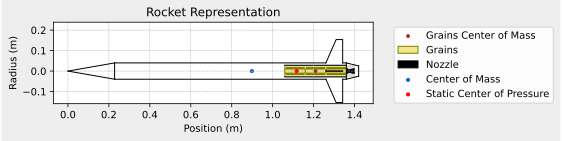


Mass Plots
----------------------------------------


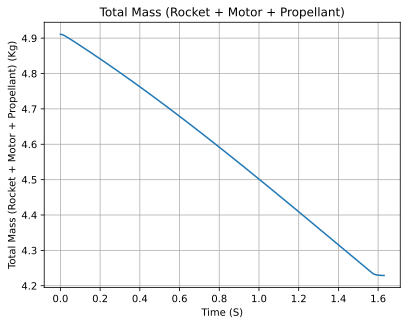

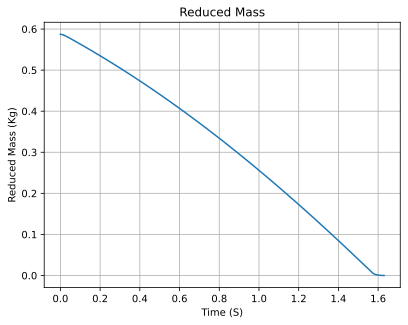


Aerodynamics Plots
----------------------------------------
Drag Plots
--------------------


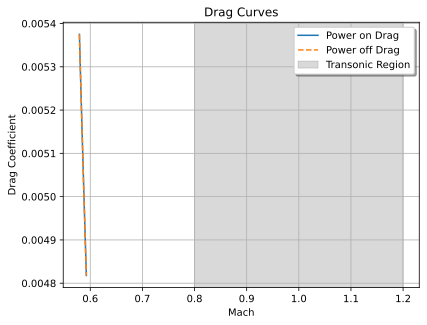


Stability Plots
--------------------


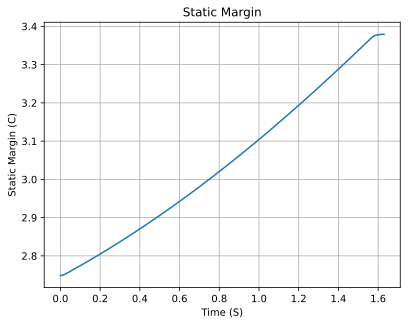

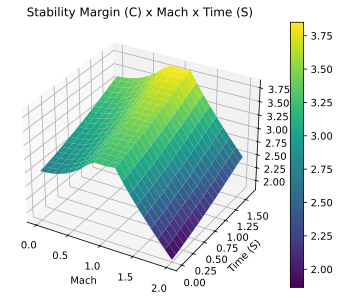


Thrust-to-Weight Plot
----------------------------------------


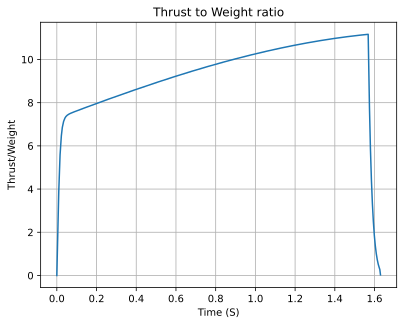

In [ ]:
FalconOneRocket.all_info()

#### Adicionando Paraquedas


Finalmente, temos os paraquedas! O FalconOneRocket terá dois paraquedas, Drogue e Main. O paraquedas Drogue abrirá no apogeu, enquanto o paraquedas Main abrirá a 800 m acima do nível do solo.

Para mais detalhes, veja [Adicionando Paraquedas](https://docs.rocketpy.org/en/latest/user/rocket.html#adding-parachutes)

In [ ]:
# %%
# ------------------------- SISTEMA DE RECUPERAÇÃO -------------------------

# Adiciona o Paraquedas Principal ao foguete
paraquedas_principal = FalconOneRocket.add_parachute(
    "ParaQuedas",
    cd_s=2.3277,          # Vamos calcular juntos (Cd * Área)
    trigger="apogee",  # Acionamento no ponto mais alto do voo
    sampling_rate=500, # Taxa de amostragem do altímetro em Hz (ex: 150)
    lag=1.5,           # Atraso da ejeção em segundos (ex: 1.5)
    noise=(0, 0.1, 0.5)  # Ruído do altímetro (média, desvio_padrão, correlação)
)


Atenção ao executar esta última célula várias vezes! Se fizer isso, seu foguete terminará com muitos paraquedas que ativam juntos, o que pode causar problemas durante a simulação de voo. Recomendamos executar novamente todas as células que definem nosso foguete antes desta, prevenindo paraquedas antigos indesejados. Como alternativa, você pode executar as linhas a seguir para remover paraquedas.

```python
FalconOneRocket.parachutes.remove(Drogue)
FalconOneRocket.parachutes.remove(Main)
```


## Simulando um Voo

Simular uma trajetória de voo é tão simples quanto inicializar um objeto da classe Flight, fornecendo o foguete e o ambiente configurados acima como entradas. A inclinação e a orientação do trilho de lançamento também são informadas aqui.


In [ ]:
test_flight = Flight(
    rocket=FalconOneRocket, environment=env, rail_length=4, inclination=80, heading=0 # Dados do trilho
)

## Analisando os Resultados

O RocketPy oferece muitos gráficos, com certeza! Eles são divididos em seções para mantê-los organizados. Como alternativa, consulte a documentação da classe Flight para ver como obter gráficos apenas de variáveis específicas, em vez de todos de uma vez.



Initial Conditions

Initial time: 0.000 s
Position - x: 0.00 m | y: 0.00 m | z: 471.48 m
Velocity - Vx: 0.00 m/s | Vy: 0.00 m/s | Vz: 0.00 m/s
Attitude (quaternions) - e0: 0.996 | e1: -0.087 | e2: 0.000 | e3: 0.000
Euler Angles - Spin φ : 0.00° | Nutation θ: -10.00° | Precession ψ: 0.00°
Angular Velocity - ω1: 0.00 rad/s | ω2: 0.00 rad/s | ω3: 0.00 rad/s
Initial Stability Margin: 2.749 c


Surface Wind Conditions

Frontal Surface Wind Speed: -1.42 m/s
Lateral Surface Wind Speed: 5.00 m/s


Launch Rail

Launch Rail Length: 4 m
Launch Rail Inclination: 80.00°
Launch Rail Heading: 0.00°


Rail Departure State

Rail Departure Time: 0.361 s
Rail Departure Velocity: 23.656 m/s
Rail Departure Stability Margin: 2.860 c
Rail Departure Angle of Attack: 12.296°
Rail Departure Thrust-Weight Ratio: 8.493
Rail Departure Reynolds Number: 1.194e+05


Burn out State

Burn out time: 1.630 s
Altitude at burn out: 570.840 m (ASL) | 99.362 m (AGL)
Rocket speed at burn out: 132.062 m/s
Freestream velocity 

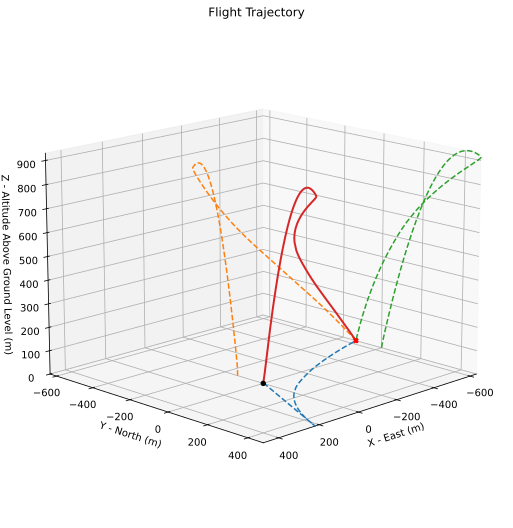



Trajectory Kinematic Plots



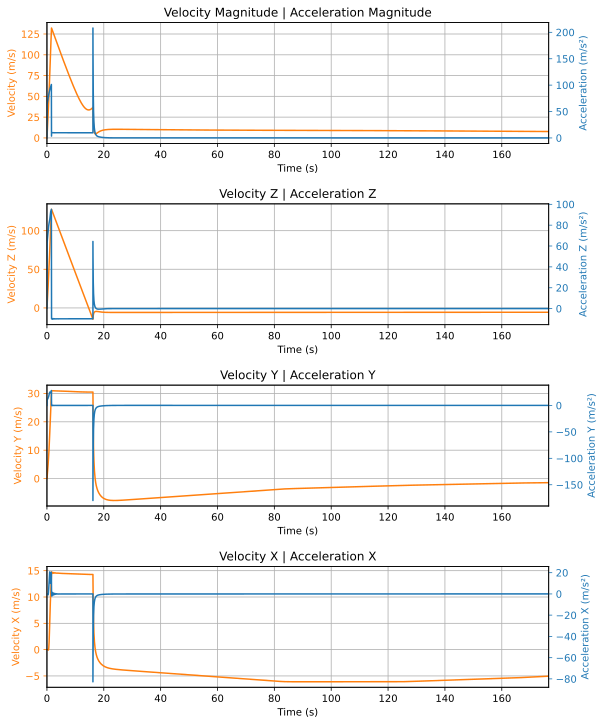



Angular Position Plots



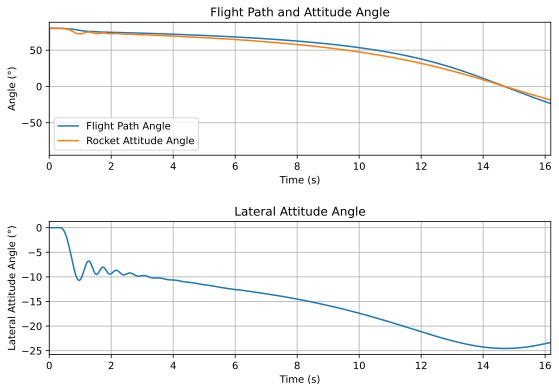



Path, Attitude and Lateral Attitude Angle plots



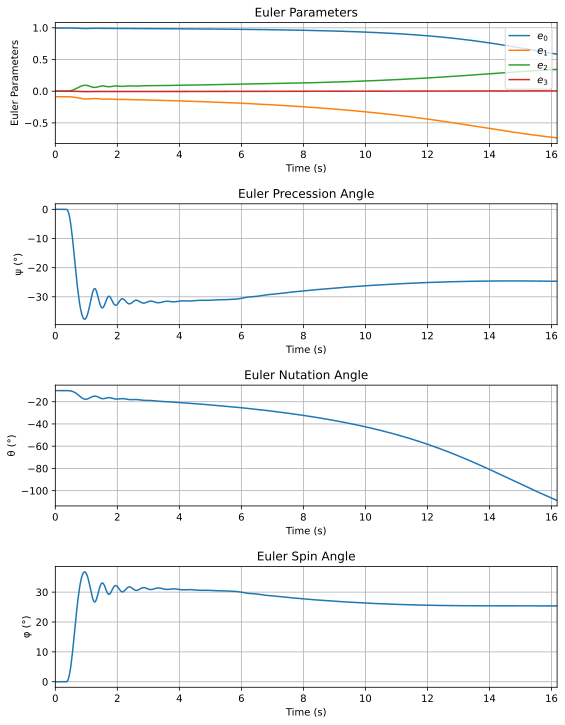



Trajectory Angular Velocity and Acceleration Plots



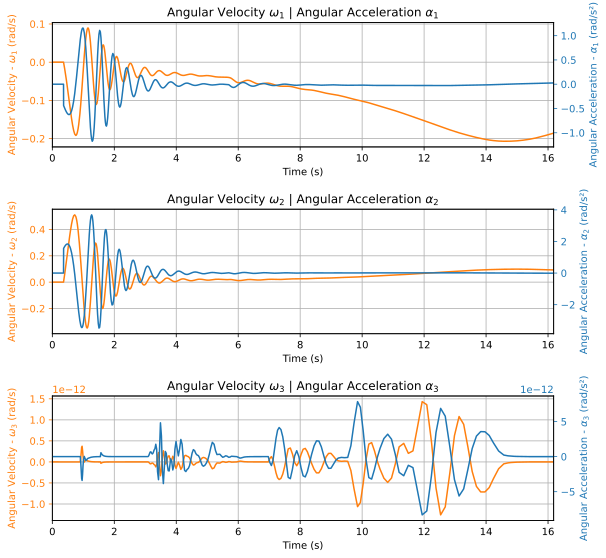



Aerodynamic Forces Plots



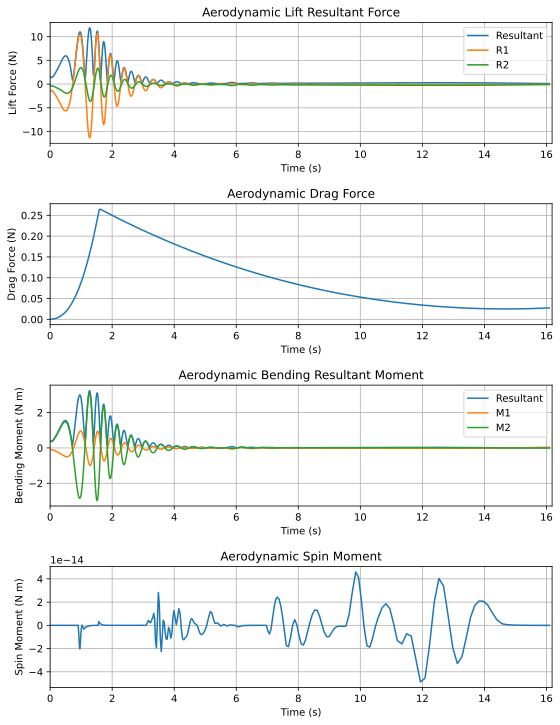



Rail Buttons Forces Plots

No rail buttons were defined. Skipping rail button plots.


Trajectory Energy Plots



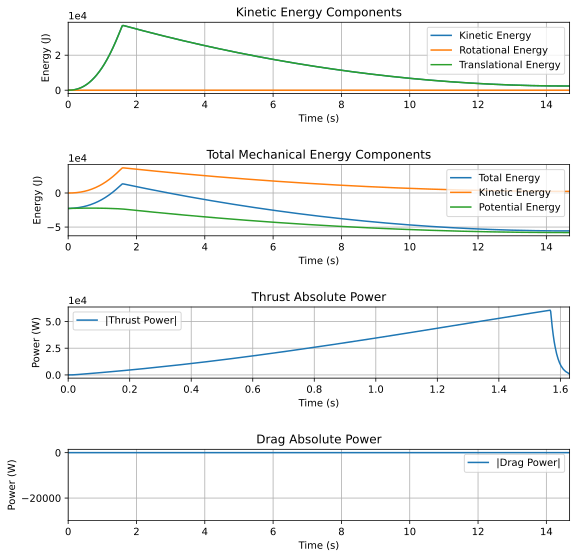



Trajectory Fluid Mechanics Plots



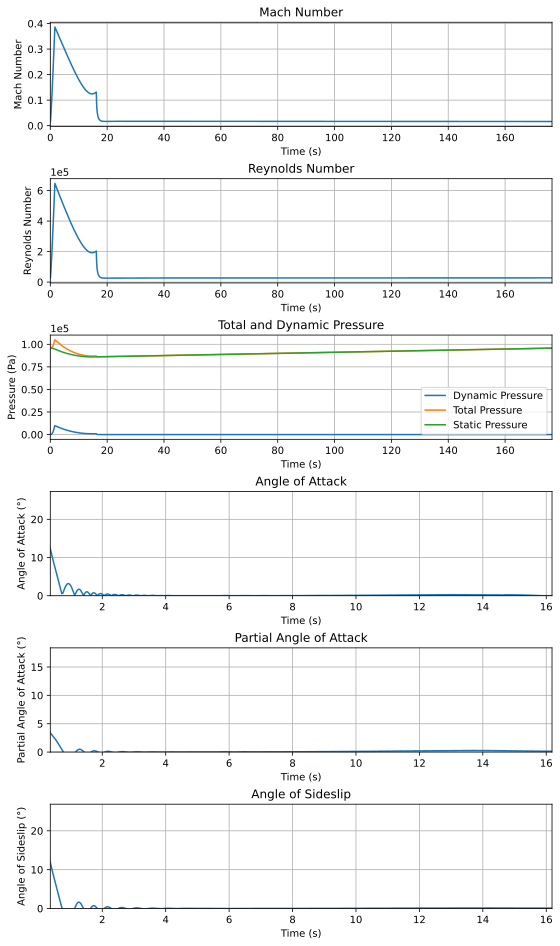



Trajectory Stability and Control Plots



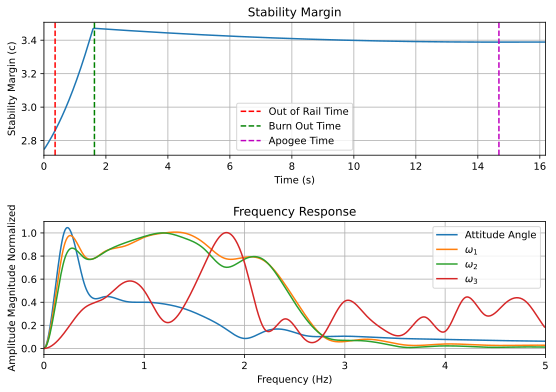



Rocket and Parachute Pressure Plots



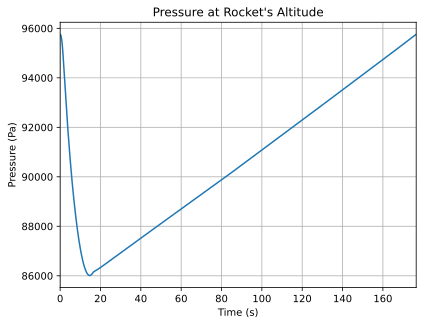


Parachute:  ParaQuedas


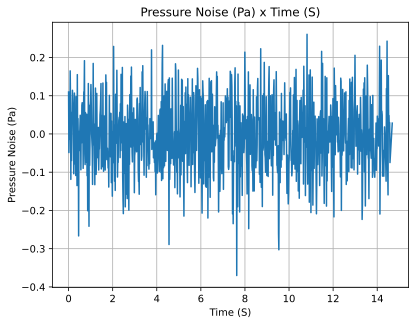

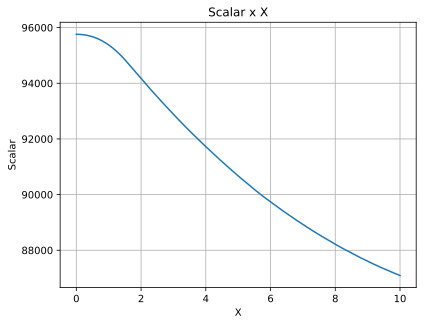

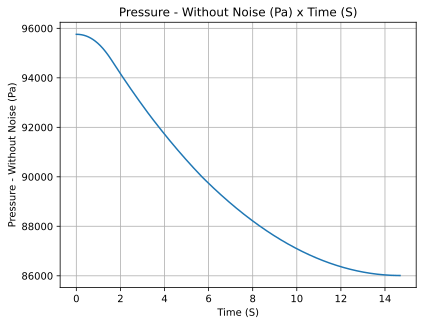

In [ ]:
test_flight.all_info()

Exporte a trajetória do voo para um arquivo .kml para que possa ser aberto no Google Earth


In [ ]:
test_flight.export_kml(
    file_name="Lançamento-LASC2025-OFICIAL 2.kml",
    extrude=True,
    altitude_mode="relative_to_ground",
)

File  Lançamento-LASC2025-OFICIAL 2.kml  saved with success!


/tmp/ipython-input-1541224410.py:1: DeprecationWarning: Moved to FlightDataExporter.export_kml() and will be removed in v1.12.0. Use `rocketpy.simulation.flight_data_exporter.FlightDataExporter.export_kml` instead.
  test_flight.export_kml(


## Usando a Simulação para Projeto

Aqui, veremos alguns exemplos que usam o RocketPy de maneiras interessantes para nos ajudar a projetar nosso foguete.


### Apogeu em Função da Massa

Este é um clássico! Sempre precisamos saber quanto o apogeu do nosso foguete mudará quando a carga útil ficar mais pesada.


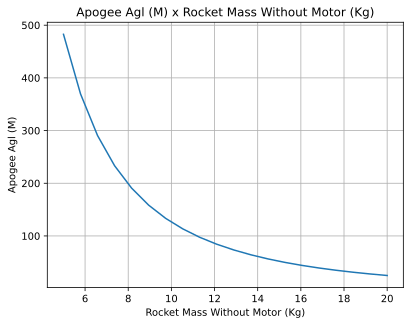

In [ ]:
from rocketpy.utilities import apogee_by_mass

# Temporarily remove the parachute to avoid conflicts with the internal simulations of apogee_by_mass
parachute_main = FalconOneRocket.parachutes.pop(0)

apogee_by_mass(flight=test_flight, min_mass=5, max_mass=20, points=20, plot=True)

# Add the parachute back
FalconOneRocket.parachutes.append(parachute_main)

### Velocidade de Saída do Trilho em Função da Massa

Vamos fazer um gráfico muito importante. A velocidade de saída do trilho é a velocidade que nosso foguete tem quando está deixando o trilho de lançamento. Isso é crucial para garantir que ele possa voar com segurança após sair do trilho. Uma regra prática comum é que a velocidade de saída do trilho do nosso foguete deve ser 4 vezes a velocidade do vento para que ele não entre em estol e se torne instável.


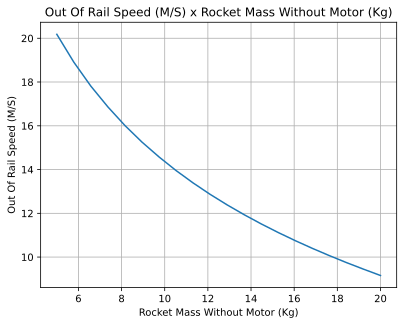

In [ ]:
from rocketpy.utilities import liftoff_speed_by_mass

# Temporarily remove the parachute to avoid conflicts with the internal simulations
parachute_main = FalconOneRocket.parachutes.pop(0)

liftoff_speed_by_mass(flight=test_flight, min_mass=5, max_mass=20, points=20, plot=True)

# Add the parachute back
FalconOneRocket.parachutes.append(parachute_main)

### Análise de Estabilidade Dinâmica

Já se perguntou como a estabilidade estática se traduz em estabilidade dinâmica? Margens estáticas diferentes resultam em comportamentos dinâmicos distintos, o que também depende da inércia rotacional do foguete.

Vamos usar a classe auxiliar do RocketPy chamada Function para explorar como a estabilidade dinâmica do FalconOneRocket varia se mudarmos a envergadura das aletas por um determinado fator.


In [ ]:
# Classe auxiliar
import copy

from rocketpy import Function

# Preparar uma cópia do foguete
FalconOneRocket2 = copy.deepcopy(FalconOneRocket)

# Preparar a classe Environment
custom_env = Environment()
custom_env.set_atmospheric_model(type="custom_atmosphere", wind_v=-5)

# Simular diferentes margens estáticas variando a posição das aletas
simulation_results = []

# Store original fins
original_fins = FalconOneRocket2.aerodynamic_surfaces.pop(-1)

for factor in [-0.5, -0.3, -0.1, 0.1, 0.3, 0.5, 0.7]: # Increased the number of points
    # Modify fin position by removing the previous one and adding a new one
    # Remove the previously added fins if they exist
    if hasattr(FalconOneRocket2, '_temp_fins'):
        try:
            FalconOneRocket2.aerodynamic_surfaces.remove(FalconOneRocket2._temp_fins)
        except ValueError:
            pass # Fins not found, continue

    fin_set = FalconOneRocket2.add_trapezoidal_fins(
        n=4,
        root_chord=0.120,
        tip_chord=0.040,
        span=0.100,
        position=1.26 + factor, # Adjust position relative to original fins position
    )
    # Store the added fins to be removed in the next iteration
    FalconOneRocket2._temp_fins = fin_set

    # Simular
    print(
        "Simulando foguete com margem estática de {:1.3f}->{:1.3f} c".format(
            FalconOneRocket2.static_margin(0),
            FalconOneRocket2.static_margin(FalconOneRocket2.motor.burn_out_time),
        )
    )
    test_flight = Flight(
        rocket=FalconOneRocket2,
        environment=custom_env,
        rail_length=5.2,
        inclination=90,
        heading=0,
        max_time_step=0.01,
        max_time=180, # Increased max_time
        terminate_on_apogee=False, # Allow simulation to go past apogee
        verbose=False, # Set verbose to False for cleaner output during loop
    )
    # Armazenar resultados
    static_margin_at_ignition = FalconOneRocket2.static_margin(0)
    static_margin_at_out_of_rail = FalconOneRocket2.static_margin(test_flight.out_of_rail_time)
    static_margin_at_steady_state = FalconOneRocket2.static_margin(test_flight.t_final)
    simulation_results += [
        (
            test_flight.attitude_angle,
            "{:1.2f} c | {:1.2f} c | {:1.2f} c".format(
                static_margin_at_ignition,
                static_margin_at_out_of_rail,
                static_margin_at_steady_state,
            ),
        )
    ]

# Add original fins back
FalconOneRocket2.aerodynamic_surfaces.append(original_fins)
# Remove temporary fins attribute
if hasattr(FalconOneRocket2, '_temp_fins'):
    del FalconOneRocket2._temp_fins


Function.compare_plots(
    simulation_results,
    lower=0,
    upper=1.5,
    xlabel="Tempo (s)",
    ylabel="Ângulo de atitude (graus)",
)

Simulando foguete com margem estática de 2.755->2.945 c


/usr/local/lib/python3.12/dist-packages/rocketpy/tools.py:250: RuntimeWarning: divide by zero encountered in scalar divide
  return (y - c) / m


IndexError: list index out of range

### Cálculo da Frequência Característica

Aqui analisamos a frequência característica de oscilação do nosso foguete assim que ele deixa o trilho de lançamento. Observe que, quando executamos test_flight.all_info(), um dos gráficos já mostrava o espectro de frequência do nosso voo. Aqui, no entanto, temos mais controle sobre o que estamos representando.


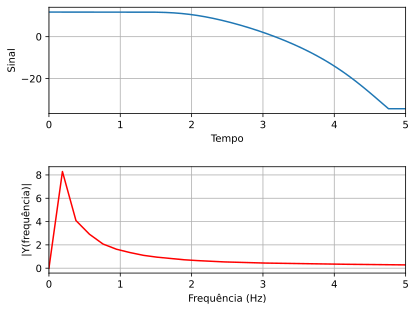

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Simular os primeiros 5 segundos de voo
flight = Flight(
    rocket=FalconOneRocket,
    environment=env,
    rail_length=5.2,
    inclination=90,
    heading=0,
    max_time_step=0.01,
    max_time=5,
)

# Realizar uma análise de Fourier
Fs = 100.0
# taxa de amostragem
Ts = 1.0 / Fs
# intervalo de amostragem
# Get time and attitude angle data from the flight results
solution = np.array(flight.solution) # Convert the solution to a NumPy array
t = solution[:, 0] # Time is in the first column of the solution
y = np.degrees(solution[:, 7]) # Attitude angle is in the 8th column, convert from radians to degrees
# Ensure t and y have the same length for FFT
min_len = min(len(t), len(y))
t = t[:min_len]
y = y[:min_len]

# Perform Fourier analysis only if there's enough data
if len(y) > 0:
    y_mean = np.mean(y)
    y_detrended = y - y_mean

    n = len(y_detrended)  # comprimento do sinal
    k = np.arange(n)
    T = n / Fs
    frq = k / T  # faixa de frequência de dois lados
    frq = frq[range(n // 2)]  # faixa de frequência de um lado
    Y = np.fft.fft(y_detrended) / n  # cálculo e normalização da FFT
    Y = Y[range(n // 2)]

    # Criar o gráfico
    fig, ax = plt.subplots(2, 1)
    ax[0].plot(t, y_detrended)
    ax[0].set_xlabel("Tempo")
    ax[0].set_ylabel("Sinal")
    ax[0].set_xlim((0, min(5, t[-1] if len(t) > 0 else 5))) # Adjust xlim based on actual flight time
    ax[0].grid()
    ax[1].plot(frq, abs(Y), "r")  # plotando o espectro
    ax[1].set_xlabel("Frequência (Hz)")
    ax[1].set_ylabel("|Y(frequência)|")
    ax[1].set_xlim((0, 5))
    ax[1].grid()
    plt.subplots_adjust(hspace=0.5)
    plt.show()
else:
    print("Not enough data to perform Fourier analysis.")

In [ ]:
from google.colab import drive # Deixa salvo os Dados no seu drive
drive.mount('/content/drive')

Mounted at /content/drive
